# Evaluate trained models on June 19 mixture data

Dataset:

`data/live_rapid_e/parsed/june19_bacillus25_micrococcus75_1426_1442_preprocessed.parquet`

Expected composition:

- **25% Bacillus** — treated here as `B. cereus`
- **75% Micrococcus** — treated here as `M. luteus`

This notebook loads every deployable model bundle in `models/trained/`, runs inference on the June 19 preprocessed parquet, and summarizes predicted composition per model.


In [1]:
from __future__ import annotations

import json
import importlib
from pathlib import Path
from typing import Any

import joblib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset

PROJECT_ROOT = Path(r"C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis")

import sys

SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("Added to path:", SRC_PATH)

DATA_PATH = PROJECT_ROOT / r"data\live_rapid_e\parsed\june19_bacillus25_micrococcus75_1426_1442_preprocessed.parquet"
MODELS_DIR = PROJECT_ROOT / "models" / "trained"
OUTPUT_DIR = PROJECT_ROOT / "results" / "june19_model_comparison"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED = {
    "Bacillus": 0.25,
    "Micrococcus": 0.75,
}

BACILLUS_LABELS = {"B. cereus", "B_cereus", "Bacillus cereus", "bacillus", "bacillus_cereus"}
MICROCOCCUS_LABELS = {"M. luteus", "M_luteus", "Micrococcus luteus", "micrococcus", "micrococcus_luteus"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Data path:", DATA_PATH)
print("Models dir:", MODELS_DIR)


Added to path: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\src
Device: cpu
Data path: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\data\live_rapid_e\parsed\june19_bacillus25_micrococcus75_1426_1442_preprocessed.parquet
Models dir: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\models\trained


In [2]:
df = pd.read_parquet(DATA_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.columns[:30].tolist())

if "peak_fluorescence" in df.columns:
    print("\nPeak fluorescence summary:")
    print(df["peak_fluorescence"].describe())

print("\nFirst few columns by prefix:")
for prefix in ["fs_", "lt_", "si_"]:
    cols = [c for c in df.columns if c.startswith(prefix)]
    print(prefix, len(cols), cols[:5])


Rows: 3894
Columns: 1976
['raw_file', 'raw_path', 'particle_index', 'timestamp', 'serial', 'version', 'number_of_modules', 'has_fluorescence', 'lt11_framelength', 'lt03_framelength', 'lt04_framelength', 'image_size', 'scattering_emitter_id', 'scattering_detection_id', 'crc_ok', 'footer_ok', 'size', 'time_asymmetry', 'source_file', 'source_path', 'peak_fluorescence', 'fs_0000', 'fs_0001', 'fs_0002', 'fs_0003', 'fs_0004', 'fs_0005', 'fs_0006', 'fs_0007', 'fs_0008']

Peak fluorescence summary:
count     3894.000000
mean     11009.222393
std       6889.869562
min       2000.000000
25%       3828.750000
50%      10541.500000
75%      17569.250000
max      22106.000000
Name: peak_fluorescence, dtype: float64

First few columns by prefix:
fs_ 256 ['fs_0000', 'fs_0001', 'fs_0002', 'fs_0003', 'fs_0004']
lt_ 256 ['lt_0000', 'lt_0001', 'lt_0002', 'lt_0003', 'lt_0004']
si_ 1440 ['si_0000', 'si_0001', 'si_0002', 'si_0003', 'si_0004']


In [3]:
def sorted_prefixed_columns(frame: pd.DataFrame, prefix: str) -> list[str]:
    cols = [c for c in frame.columns if c.startswith(prefix)]
    return sorted(cols, key=lambda x: int(x.split("_")[1]) if x.split("_")[1].isdigit() else x)


def get_feature_block(frame: pd.DataFrame, logical_name: str) -> np.ndarray:
    """
    Return a 2D matrix for a logical feature group from either flattened
    preprocessed columns or original array columns.
    """
    if logical_name in {"spectrometer", "fluorescence_spectra", "spectra"}:
        fs_cols = sorted_prefixed_columns(frame, "fs_")
        if fs_cols:
            return frame[fs_cols].to_numpy(dtype=np.float32)
        for col in ["fluorescence_spectra", "spectrometer"]:
            if col in frame.columns:
                return np.stack(frame[col].apply(np.asarray).values).astype(np.float32)

    if logical_name in {"lifetime", "fluorescence_lifetime"}:
        lt_cols = sorted_prefixed_columns(frame, "lt_")
        if lt_cols:
            return frame[lt_cols].to_numpy(dtype=np.float32)
        for col in ["fluorescence_lifetime", "lifetime"]:
            if col in frame.columns:
                return np.stack(frame[col].apply(np.asarray).values).astype(np.float32)

    if logical_name in {"scattering", "scattering_image"}:
        si_cols = sorted_prefixed_columns(frame, "si_")
        if si_cols:
            return frame[si_cols].to_numpy(dtype=np.float32)
        for col in ["scattering", "scattering_processed", "scattering_image"]:
            if col in frame.columns:
                arr = np.stack(frame[col].apply(lambda x: np.asarray(x).flatten()).values)
                return arr.astype(np.float32)

    raise ValueError(f"Could not build feature block: {logical_name}")


def build_matrix_from_feature_names(frame: pd.DataFrame, feature_names: list[str]) -> np.ndarray:
    """
    Build a matrix using saved RF feature names. Supports names like:
    spectrometer_0, lifetime_0, scattering_0, size, time_asymmetry.
    """
    spec = None
    life = None
    scat = None
    parts = []

    for name in feature_names:
        if name in frame.columns:
            parts.append(frame[name].to_numpy(dtype=np.float32).reshape(-1, 1))
            continue

        if name.startswith("spectrometer_"):
            if spec is None:
                spec = get_feature_block(frame, "spectrometer")
            idx = int(name.split("_")[-1])
            parts.append(spec[:, idx].reshape(-1, 1))
            continue

        if name.startswith("lifetime_"):
            if life is None:
                life = get_feature_block(frame, "lifetime")
            idx = int(name.split("_")[-1])
            parts.append(life[:, idx].reshape(-1, 1))
            continue

        if name.startswith("scattering_"):
            if scat is None:
                scat = get_feature_block(frame, "scattering")
            idx = int(name.split("_")[-1])
            parts.append(scat[:, idx].reshape(-1, 1))
            continue

        if name in {"size", "time_asymmetry"}:
            parts.append(pd.to_numeric(frame[name], errors="coerce").to_numpy(dtype=np.float32).reshape(-1, 1))
            continue

        raise ValueError(f"Could not resolve feature name: {name}")

    X = np.concatenate(parts, axis=1).astype(np.float32)

    if not np.isfinite(X).all():
        raise ValueError("Feature matrix contains NaN/Inf")

    return X


def load_json(path: Path) -> dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def labels_from_bundle(model_dir: Path, checkpoint: dict | None = None) -> list[str]:
    labels_path = model_dir / "labels.json"
    if labels_path.exists():
        raw = load_json(labels_path)
        return [raw[str(i)] for i in range(len(raw))]
    if checkpoint and "class_names" in checkpoint:
        return list(checkpoint["class_names"])
    raise FileNotFoundError(f"No labels found for {model_dir.name}")


def normalize_species_group(label: str) -> str:
    s = str(label).strip()
    sl = s.lower().replace("_", " ")

    if s in BACILLUS_LABELS or "b. cereus" in sl or "bacillus" in sl or "cereus" in sl:
        return "Bacillus"

    if s in MICROCOCCUS_LABELS or "m. luteus" in sl or "micrococcus" in sl or "luteus" in sl:
        return "Micrococcus"

    if sl == "unknown":
        return "Unknown"

    return "Other"


def summarize_predictions(pred_df: pd.DataFrame, model_id: str) -> dict[str, Any]:
    label_col = "robust_prediction" if "robust_prediction" in pred_df.columns else "predicted_label"

    counts = pred_df[label_col].value_counts(dropna=False)
    fractions = pred_df[label_col].value_counts(normalize=True, dropna=False)

    group = pred_df[label_col].map(normalize_species_group)
    group_counts = group.value_counts(dropna=False)
    group_fractions = group.value_counts(normalize=True, dropna=False)

    bacillus_fraction = float(group_fractions.get("Bacillus", 0.0))
    micrococcus_fraction = float(group_fractions.get("Micrococcus", 0.0))
    unknown_fraction = float(group_fractions.get("Unknown", 0.0))
    other_fraction = float(group_fractions.get("Other", 0.0))

    known_mask = ~group.isin(["Unknown"])
    known_group_fractions = group[known_mask].value_counts(normalize=True, dropna=False) if known_mask.any() else pd.Series(dtype=float)

    bacillus_known_fraction = float(known_group_fractions.get("Bacillus", 0.0))
    micrococcus_known_fraction = float(known_group_fractions.get("Micrococcus", 0.0))

    return {
        "model_id": model_id,
        "n_particles": int(len(pred_df)),
        "bacillus_fraction": bacillus_fraction,
        "micrococcus_fraction": micrococcus_fraction,
        "unknown_fraction": unknown_fraction,
        "other_fraction": other_fraction,
        "bacillus_known_fraction": bacillus_known_fraction,
        "micrococcus_known_fraction": micrococcus_known_fraction,
        "bacillus_abs_error": abs(bacillus_fraction - EXPECTED["Bacillus"]),
        "micrococcus_abs_error": abs(micrococcus_fraction - EXPECTED["Micrococcus"]),
        "label_counts": counts.to_dict(),
        "label_fractions": fractions.to_dict(),
        "group_counts": group_counts.to_dict(),
        "group_fractions": group_fractions.to_dict(),
    }


In [4]:
class CNN1DDataset(Dataset):
    def __init__(self, X: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0)


class MultimodalDataset(Dataset):
    def __init__(self, X_spec, X_life, X_scat, X_scalar):
        self.X_spec = torch.tensor(X_spec, dtype=torch.float32)
        self.X_life = torch.tensor(X_life, dtype=torch.float32)
        self.X_scat = torch.tensor(X_scat, dtype=torch.float32)
        self.X_scalar = torch.tensor(X_scalar, dtype=torch.float32)

    def __len__(self):
        return len(self.X_scalar)

    def __getitem__(self, idx):
        return {
            "spectrometer": self.X_spec[idx].unsqueeze(0),
            "lifetime": self.X_life[idx].unsqueeze(0),
            "scattering": self.X_scat[idx].unsqueeze(0),
            "scalar": self.X_scalar[idx],
        }


@torch.no_grad()
def predict_torch_cnn1d(model_dir: Path, frame: pd.DataFrame) -> pd.DataFrame:
    checkpoint = torch.load(model_dir / "model.pt", map_location=device)
    labels = labels_from_bundle(model_dir, checkpoint)

    module = importlib.import_module(checkpoint.get("model_module", "lif_thesis.models.cnn1d"))
    ModelClass = getattr(module, checkpoint.get("architecture", "BaselineCNN1D"))

    model = ModelClass(
        input_length=int(checkpoint["input_length"]),
        n_classes=int(checkpoint["n_classes"]),
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    X = get_feature_block(frame, "spectrometer")

    scaler_path = model_dir / "spectra_scaler.joblib"
    if scaler_path.exists():
        scaler = joblib.load(scaler_path)
        X = scaler.transform(X)

    loader = DataLoader(CNN1DDataset(X), batch_size=512, shuffle=False)

    all_proba = []
    for xb in loader:
        xb = xb.to(device)
        logits = model(xb)
        proba = torch.softmax(logits, dim=1).cpu().numpy()
        all_proba.append(proba)

    proba = np.concatenate(all_proba, axis=0)
    pred_idx = proba.argmax(axis=1)
    pred_labels = [labels[i] for i in pred_idx]

    out = pd.DataFrame({
        "predicted_label": pred_labels,
        "prediction_confidence": proba.max(axis=1),
    })

    for i, label in enumerate(labels):
        out[f"prob_{label}"] = proba[:, i]

    return out


def apply_rejection(proba: np.ndarray, X_scalar_scaled: np.ndarray, checkpoint: dict) -> tuple[np.ndarray, dict]:
    rejection_config = checkpoint.get("rejection_config", {})
    softmax_threshold = float(rejection_config.get("softmax_threshold", 0.80))
    margin_threshold = float(rejection_config.get("margin_threshold", 0.15))
    entropy_threshold = rejection_config.get("entropy_threshold", None)
    use_distance = bool(rejection_config.get("use_train_distance_rejection", True))

    max_proba = proba.max(axis=1)
    sorted_p = np.sort(proba, axis=1)
    margin = sorted_p[:, -1] - sorted_p[:, -2] if proba.shape[1] > 1 else np.ones(len(proba))
    safe = np.clip(proba, 1e-12, 1.0)
    entropy = -(safe * np.log(safe)).sum(axis=1)

    rejected = max_proba < softmax_threshold
    rejected |= margin < margin_threshold

    if entropy_threshold is not None:
        rejected |= entropy > float(entropy_threshold)

    distance_threshold = None
    scalar_distance = None

    distance_reference = checkpoint.get("distance_reference")
    if use_distance and distance_reference is not None:
        center = np.asarray(distance_reference["center"], dtype=float)
        scale = np.asarray(distance_reference["scale"], dtype=float)
        scalar_distance = np.linalg.norm((X_scalar_scaled - center) / scale, axis=1)
        distance_threshold = distance_reference.get("distance_threshold")
        if distance_threshold is not None:
            rejected |= scalar_distance > float(distance_threshold)

    diagnostics = {
        "max_proba": max_proba,
        "margin": margin,
        "entropy": entropy,
        "scalar_distance": scalar_distance,
        "distance_threshold": distance_threshold,
    }

    return rejected, diagnostics


@torch.no_grad()
def predict_torch_multimodal(model_dir: Path, frame: pd.DataFrame) -> pd.DataFrame:
    checkpoint = torch.load(model_dir / "model.pt", map_location=device)
    labels = labels_from_bundle(model_dir, checkpoint)

    module_name = checkpoint.get("model_module")
    architecture = checkpoint.get("architecture")

    if module_name is None:
        if "robust" in model_dir.name or "Robust" in str(architecture):
            module_name = "lif_thesis.models.robust_multimodal_cnn"
            architecture = architecture or "RobustMultimodalClassifier"
        else:
            module_name = "lif_thesis.models.multimodal_cnn"
            architecture = architecture or "MultimodalDeepClassifier"

    module = importlib.import_module(module_name)
    ModelClass = getattr(module, architecture)

    kwargs = {"n_classes": int(checkpoint["n_classes"])}
    if architecture == "RobustMultimodalClassifier":
        kwargs["modality_dropout_p"] = 0.0

    model = ModelClass(**kwargs).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    X_spec = get_feature_block(frame, "spectrometer")
    X_life = get_feature_block(frame, "lifetime")
    X_scat = get_feature_block(frame, "scattering")

    scalar_cols = ["size", "time_asymmetry"]
    X_scalar = frame[scalar_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)

    scalers = {
        "spectrometer": model_dir / "spectrometer_scaler.joblib",
        "lifetime": model_dir / "lifetime_scaler.joblib",
        "scattering": model_dir / "scattering_scaler.joblib",
        "scalar": model_dir / "scalar_scaler.joblib",
    }

    if scalers["spectrometer"].exists():
        X_spec = joblib.load(scalers["spectrometer"]).transform(X_spec)
    if scalers["lifetime"].exists():
        X_life = joblib.load(scalers["lifetime"]).transform(X_life)
    if scalers["scattering"].exists():
        X_scat = joblib.load(scalers["scattering"]).transform(X_scat)
    if scalers["scalar"].exists():
        X_scalar = joblib.load(scalers["scalar"]).transform(X_scalar)

    loader = DataLoader(
        MultimodalDataset(X_spec, X_life, X_scat, X_scalar),
        batch_size=512,
        shuffle=False,
    )

    all_proba = []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(batch)
        proba = torch.softmax(logits, dim=1).cpu().numpy()
        all_proba.append(proba)

    proba = np.concatenate(all_proba, axis=0)
    pred_idx = proba.argmax(axis=1)
    pred_labels = np.asarray([labels[i] for i in pred_idx], dtype=object)

    out = pd.DataFrame({
        "predicted_label": pred_labels,
        "prediction_confidence": proba.max(axis=1),
    })

    for i, label in enumerate(labels):
        out[f"prob_{label}"] = proba[:, i]

    if checkpoint.get("rejection_config") is not None or "robust" in model_dir.name:
        rejected, diag = apply_rejection(proba, X_scalar, checkpoint)
        robust_labels = pred_labels.copy()
        robust_labels[rejected] = "unknown"

        out["robust_prediction"] = robust_labels
        out["unknown_flag"] = rejected
        out["margin"] = diag["margin"]
        out["entropy"] = diag["entropy"]
        if diag["scalar_distance"] is not None:
            out["scalar_distance"] = diag["scalar_distance"]

    return out


def predict_sklearn(model_dir: Path, frame: pd.DataFrame) -> pd.DataFrame:
    model = joblib.load(model_dir / "model.joblib")

    checkpoint_path = model_dir / "checkpoint.json"
    if checkpoint_path.exists():
        checkpoint = load_json(checkpoint_path)
    else:
        checkpoint = {}

    labels = labels_from_bundle(model_dir, checkpoint)

    feature_names = checkpoint.get("feature_names")
    if feature_names is None:
        feature_path = model_dir / "feature_names.json"
        if feature_path.exists():
            feature_names = load_json(feature_path)
        else:
            raise FileNotFoundError(f"No feature names found for {model_dir.name}")

    X = build_matrix_from_feature_names(frame, feature_names)

    pred_idx = model.predict(X)
    pred_labels = [labels[int(i)] for i in pred_idx]

    out = pd.DataFrame({
        "predicted_label": pred_labels,
    })

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        out["prediction_confidence"] = proba.max(axis=1)
        for i, label in enumerate(labels):
            out[f"prob_{label}"] = proba[:, i]

    return out


def predict_model_bundle(model_dir: Path, frame: pd.DataFrame) -> pd.DataFrame:
    metadata = load_json(model_dir / "metadata.json")
    model_type = metadata.get("model_type", "")

    if (model_dir / "model.joblib").exists():
        return predict_sklearn(model_dir, frame)

    if model_type == "torch_cnn1d" or metadata.get("architecture") == "BaselineCNN1D":
        return predict_torch_cnn1d(model_dir, frame)

    if model_type in {"torch_multimodal", "torch_multimodal_robust"}:
        return predict_torch_multimodal(model_dir, frame)

    if (model_dir / "model.pt").exists():
        checkpoint = torch.load(model_dir / "model.pt", map_location=device)
        arch = checkpoint.get("architecture", "")
        if arch == "BaselineCNN1D":
            return predict_torch_cnn1d(model_dir, frame)
        return predict_torch_multimodal(model_dir, frame)

    raise ValueError(f"Unsupported model bundle: {model_dir}")


In [5]:
model_dirs = sorted(
    p for p in MODELS_DIR.iterdir()
    if p.is_dir() and (p / "metadata.json").exists()
)

print("Found model bundles:")
for p in model_dirs:
    print("-", p.name)


Found model bundles:
- exp00_paper_rf_v1
- exp01_grouped_paper_rf_v1
- exp02_grouped_engineered_rf_v1
- exp03_tuned_rf_v1
- exp04_baseline_cnn_v1
- exp05_multimodal_species_v1
- exp06_robust_multimodal_species_v1


In [6]:
all_summaries = []
prediction_frames = {}

for model_dir in model_dirs:
    model_id = model_dir.name
    print("\n" + "=" * 100)
    print("Evaluating:", model_id)

    try:
        pred = predict_model_bundle(model_dir, df)
        pred.insert(0, "model_id", model_id)

        prediction_frames[model_id] = pred

        summary = summarize_predictions(pred, model_id=model_id)
        all_summaries.append(summary)

        out_path = OUTPUT_DIR / f"{model_id}_june19_predictions.csv"
        pred.to_csv(out_path, index=False)

        print("Saved predictions:", out_path)
        print("Predicted composition:")
        print({
            "Bacillus": summary["bacillus_fraction"],
            "Micrococcus": summary["micrococcus_fraction"],
            "Unknown": summary["unknown_fraction"],
            "Other": summary["other_fraction"],
        })

    except Exception as exc:
        print("FAILED:", model_id)
        print(type(exc).__name__, exc)
        all_summaries.append({
            "model_id": model_id,
            "error": f"{type(exc).__name__}: {exc}",
        })

summary_df = pd.DataFrame(all_summaries)
summary_df



Evaluating: exp00_paper_rf_v1


c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packa

Saved predictions: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june19_model_comparison\exp00_paper_rf_v1_june19_predictions.csv
Predicted composition:
{'Bacillus': 0.022085259373394967, 'Micrococcus': 0.9648176682074987, 'Unknown': 0.0, 'Other': 0.013097072419106317}

Evaluating: exp01_grouped_paper_rf_v1
Saved predictions: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june19_model_comparison\exp01_grouped_paper_rf_v1_june19_predictions.csv
Predicted composition:
{'Bacillus': 0.04571135079609656, 'Micrococcus': 0.9357986646122239, 'Unknown': 0.0, 'Other': 0.01848998459167951}

Evaluating: exp02_grouped_engineered_rf_v1


c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Saved predictions: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june19_model_comparison\exp02_grouped_engineered_rf_v1_june19_predictions.csv
Predicted composition:
{'Bacillus': 0.001027221366204417, 'Micrococcus': 0.9488957370313302, 'Unknown': 0.0, 'Other': 0.05007704160246533}

Evaluating: exp03_tuned_rf_v1


...

c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base

Saved predictions: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june19_model_comparison\exp05_multimodal_species_v1_june19_predictions.csv
Predicted composition:
{'Bacillus': 0.02465331278890601, 'Micrococcus': 0.0005136106831022085, 'Unknown': 0.0, 'Other': 0.9748330765279918}

Evaluating: exp06_robust_multimodal_species_v1


c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base

Saved predictions: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june19_model_comparison\exp06_robust_multimodal_species_v1_june19_predictions.csv
Predicted composition:
{'Bacillus': 0.0017976373908577298, 'Micrococcus': 0.0007704160246533128, 'Unknown': 0.29198767334360554, 'Other': 0.7054442732408834}


,model_id,n_particles,bacillus_fraction,micrococcus_fraction,unknown_fraction,other_fraction,bacillus_known_fraction,micrococcus_known_fraction,bacillus_abs_error,micrococcus_abs_error,label_counts,label_fractions,group_counts,group_fractions
0,exp00_paper_rf_v1,3894,0.022085,0.964818,0.000000,0.013097,0.022085,0.964818,0.227915,0.214818,"{'M. luteus': 3757, 'B. cereus': 86, 'B. endop...","{'M. luteus': 0.9648176682074987, 'B. cereus':...","{'Micrococcus': 3757, 'Bacillus': 86, 'Other':...","{'Micrococcus': 0.9648176682074987, 'Bacillus'..."
1,exp01_grouped_paper_rf_v1,3894,0.045711,0.935799,0.000000,0.018490,0.045711,0.935799,0.204289,0.185799,"{'M. luteus': 3644, 'B. cereus': 178, 'B. endo...","{'M. luteus': 0.9357986646122239, 'B. cereus':...","{'Micrococcus': 3644, 'Bacillus': 178, 'Other'...","{'Micrococcus': 0.9357986646122239, 'Bacillus'..."
2,exp02_grouped_engineered_rf_v1,3894,0.001027,0.948896,0.000000,0.050077,0.001027,0.948896,0.248973,0.198896,"{'M. luteus': 3695, 'B. endophyticus': 194, 'B...","{'M. luteus': 0.9488957370313302, 'B. endophyt...","{'Micrococcus': 3695, 'Other': 195, 'Bacillus'...","{'Micrococcus': 0.9488957370313302, 'Other': 0..."
3,exp03_tuned_rf_v1,3894,0.003595,0.915511,0.000000,0.080894,0.003595,0.915511,0.246405,0.165511,"{'M. luteus': 3565, 'B. endophyticus': 314, 'B...","{'M. luteus': 0.9155110426296867, 'B. endophyt...","{'Micrococcus': 3565, 'Other': 315, 'Bacillus'...","{'Micrococcus': 0.9155110426296867, 'Other': 0..."
4,exp04_baseline_cnn_v1,3894,0.741140,0.116076,0.000000,0.142784,0.741140,0.116076,0.491140,0.633924,"{'B. cereus': 2886, 'M. luteus': 452, 'S. humi...","{'B. cereus': 0.7411402157164869, 'M. luteus':...","{'Bacillus': 2886, 'Other': 556, 'Micrococcus'...","{'Bacillus': 0.7411402157164869, 'Other': 0.14..."
5,exp05_multimodal_species_v1,3894,0.024653,0.000514,0.000000,0.974833,0.024653,0.000514,0.225347,0.749486,"{'B. endophyticus': 3790, 'B. cereus': 96, 'S....","{'B. endophyticus': 0.9732922444786851, 'B. ce...","{'Other': 3796, 'Bacillus': 96, 'Micrococcus': 2}","{'Other': 0.9748330765279918, 'Bacillus': 0.02..."
6,exp06_robust_multimodal_species_v1,3894,0.001798,0.000770,0.291988,0.705444,0.002539,0.001088,0.248202,0.749230,"{'B. endophyticus': 2747, 'unknown': 1137, 'B....","{'B. endophyticus': 0.7054442732408834, 'unkno...","{'Other': 2747, 'Unknown': 1137, 'Bacillus': 7...","{'Other': 0.7054442732408834, 'Unknown': 0.291..."


In [7]:
display_cols = [
    "model_id",
    "n_particles",
    "bacillus_fraction",
    "micrococcus_fraction",
    "unknown_fraction",
    "other_fraction",
    "bacillus_known_fraction",
    "micrococcus_known_fraction",
    "bacillus_abs_error",
    "micrococcus_abs_error",
    "error",
]

for col in display_cols:
    if col not in summary_df.columns:
        summary_df[col] = np.nan

comparison = summary_df[display_cols].copy()
comparison = comparison.sort_values(
    by=["bacillus_abs_error", "micrococcus_abs_error"],
    na_position="last",
)

comparison.to_csv(OUTPUT_DIR / "june19_model_comparison_summary.csv", index=False)

comparison


,model_id,n_particles,bacillus_fraction,micrococcus_fraction,unknown_fraction,other_fraction,bacillus_known_fraction,micrococcus_known_fraction,bacillus_abs_error,micrococcus_abs_error,error
1,exp01_grouped_paper_rf_v1,3894,0.045711,0.935799,0.000000,0.018490,0.045711,0.935799,0.204289,0.185799,NaN
5,exp05_multimodal_species_v1,3894,0.024653,0.000514,0.000000,0.974833,0.024653,0.000514,0.225347,0.749486,NaN
0,exp00_paper_rf_v1,3894,0.022085,0.964818,0.000000,0.013097,0.022085,0.964818,0.227915,0.214818,NaN
3,exp03_tuned_rf_v1,3894,0.003595,0.915511,0.000000,0.080894,0.003595,0.915511,0.246405,0.165511,NaN
6,exp06_robust_multimodal_species_v1,3894,0.001798,0.000770,0.291988,0.705444,0.002539,0.001088,0.248202,0.749230,NaN
2,exp02_grouped_engineered_rf_v1,3894,0.001027,0.948896,0.000000,0.050077,0.001027,0.948896,0.248973,0.198896,NaN
4,exp04_baseline_cnn_v1,3894,0.741140,0.116076,0.000000,0.142784,0.741140,0.116076,0.491140,0.633924,NaN


In [8]:
rows = []

for summary in all_summaries:
    model_id = summary.get("model_id")
    if "label_fractions" not in summary:
        continue

    for label, frac in summary["label_fractions"].items():
        rows.append({
            "model_id": model_id,
            "label": label,
            "fraction": frac,
            "count": summary["label_counts"].get(label, 0),
            "species_group": normalize_species_group(label),
        })

label_fraction_df = pd.DataFrame(rows)
label_fraction_df.to_csv(OUTPUT_DIR / "june19_model_label_fractions.csv", index=False)
label_fraction_df.sort_values(["model_id", "fraction"], ascending=[True, False])


,model_id,label,fraction,count,species_group
0,exp00_paper_rf_v1,M. luteus,0.964818,3757,Micrococcus
1,exp00_paper_rf_v1,B. cereus,0.022085,86,Bacillus
2,exp00_paper_rf_v1,B. endophyticus,0.011813,46,Other
3,exp00_paper_rf_v1,S. huminis,0.000770,3,Other
4,exp00_paper_rf_v1,K. salsicia,0.000514,2,Other
5,exp01_grouped_paper_rf_v1,M. luteus,0.935799,3644,Micrococcus
6,exp01_grouped_paper_rf_v1,B. cereus,0.045711,178,Bacillus
7,exp01_grouped_paper_rf_v1,B. endophyticus,0.012583,49,Other
8,exp01_grouped_paper_rf_v1,K. salsicia,0.005907,23,Other
9,exp02_grouped_engineered_rf_v1,M. luteus,0.948896,3695,Micrococcus


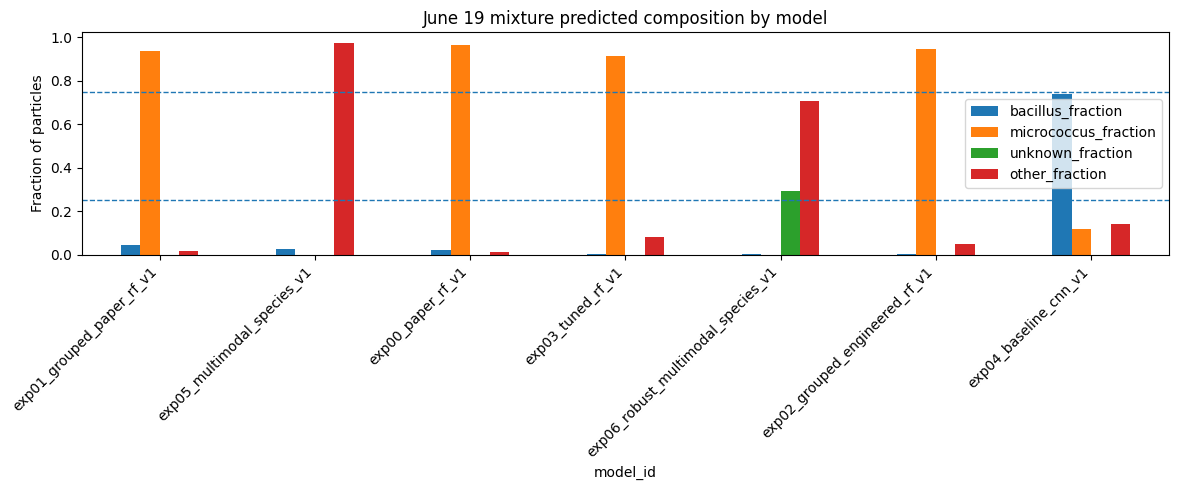

In [9]:
import matplotlib.pyplot as plt

plot_df = comparison.dropna(subset=["bacillus_fraction", "micrococcus_fraction"]).copy()

if not plot_df.empty:
    ax = plot_df.set_index("model_id")[["bacillus_fraction", "micrococcus_fraction", "unknown_fraction", "other_fraction"]].plot(
        kind="bar",
        figsize=(12, 5),
    )
    ax.axhline(0.25, linestyle="--", linewidth=1)
    ax.axhline(0.75, linestyle="--", linewidth=1)
    ax.set_ylabel("Fraction of particles")
    ax.set_title("June 19 mixture predicted composition by model")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No successful model predictions to plot.")


## Interpretation guide

For this experiment, the strongest model behavior would look like:

- `bacillus_fraction` close to **0.25**
- `micrococcus_fraction` close to **0.75**
- low `other_fraction`
- low `unknown_fraction`, unless using the robust model and the live data are genuinely out-of-distribution

For the robust model, also check `bacillus_known_fraction` and `micrococcus_known_fraction`. Those normalize after excluding `unknown`, which helps separate **composition among accepted particles** from **overall rejection behavior**.


In [15]:


si_cols = [c for c in df.columns if c.startswith("si_")]
print(len(si_cols))

1440
